# 📈 Regression using California Housing Dataset

## 🎯 Objective
To build a regression model that predicts house prices using multiple features such as income, house age, and population.

## 📌 Steps Covered
- Data Loading
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Model Training (Linear Regression)
- Model Evaluation (MAE, RMSE, R²)
- Feature Scaling using StandardScaler


In [46]:
pip install numpy pandas 

Note: you may need to restart the kernel to use updated packages.


## 📂 Data Loading

We load the California Housing dataset and convert it into a pandas DataFrame for easier manipulation and analysis.

In [47]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['PRICE']= data.target


    ## 🔍 Exploratory Data Analysis (EDA)

In this step, we explore:
- Structure of the dataset
- Data types
- Summary statistics
- Distribution of features

This helps us understand the dataset before building the model.


In [48]:

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [49]:
df.isnull().sum()


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64

In [50]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [51]:
df.corr()["PRICE"].sort_values(ascending=True)

Latitude     -0.144160
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
HouseAge      0.105623
AveRooms      0.151948
MedInc        0.688075
PRICE         1.000000
Name: PRICE, dtype: float64

In [52]:
corr_matrix = df.corr().abs()
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
MedInc,1.000000,0.119034,0.326895,0.062040,0.004834,0.018766,0.079809,0.015176,0.688075
HouseAge,0.119034,1.000000,0.153277,0.077747,0.296244,0.013191,0.011173,0.108197,0.105623
AveRooms,0.326895,0.153277,1.000000,0.847621,0.072213,0.004852,0.106389,0.027540,0.151948
AveBedrms,0.062040,0.077747,0.847621,1.000000,0.066197,0.006181,0.069721,0.013344,0.046701
Population,0.004834,0.296244,0.072213,0.066197,1.000000,0.069863,0.108785,0.099773,0.024650
AveOccup,0.018766,0.013191,0.004852,0.006181,0.069863,1.000000,0.002366,0.002476,0.023737
Latitude,0.079809,0.011173,0.106389,0.069721,0.108785,0.002366,1.000000,0.924664,0.144160
Longitude,0.015176,0.108197,0.027540,0.013344,0.099773,0.002476,0.924664,1.000000,0.045967
PRICE,0.688075,0.105623,0.151948,0.046701,0.024650,0.023737,0.144160,0.045967,1.000000


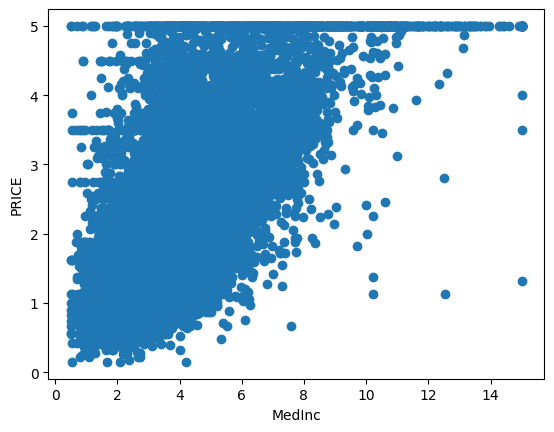

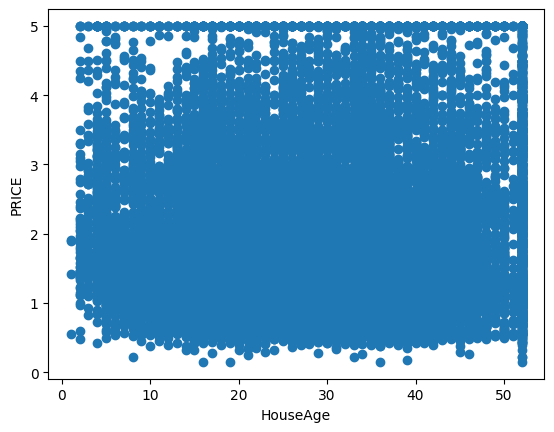

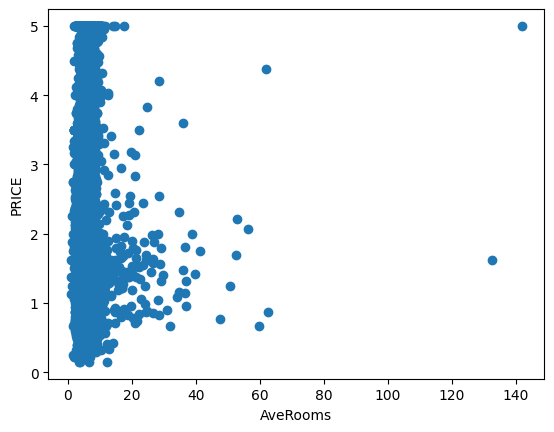

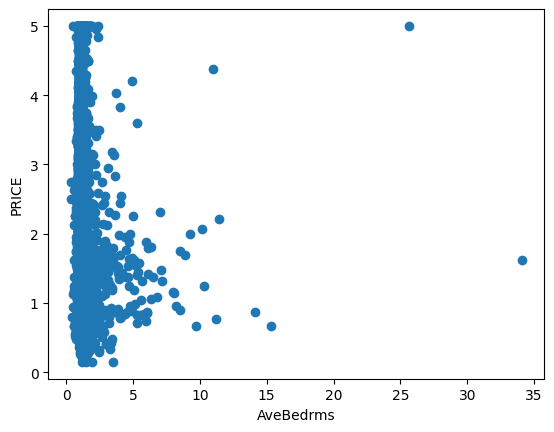

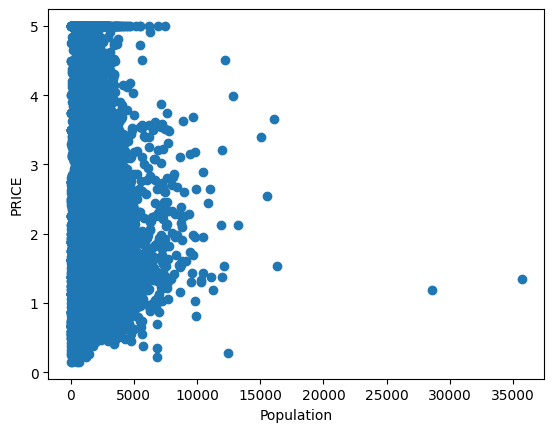

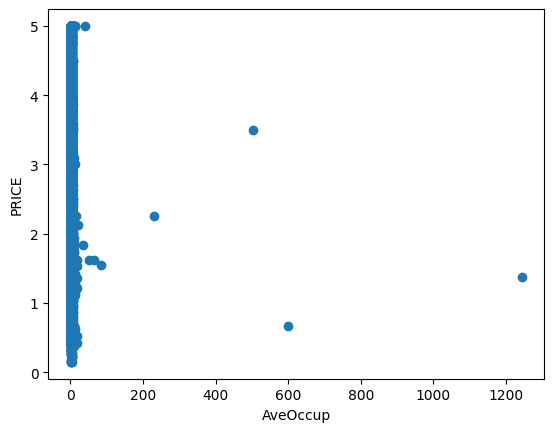

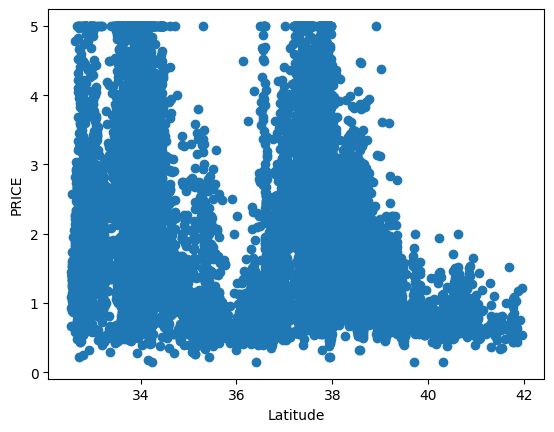

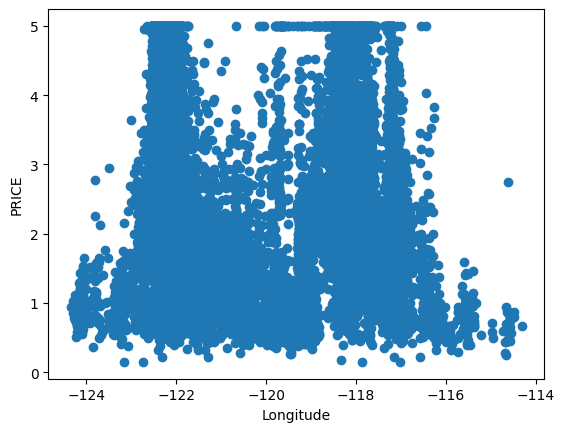

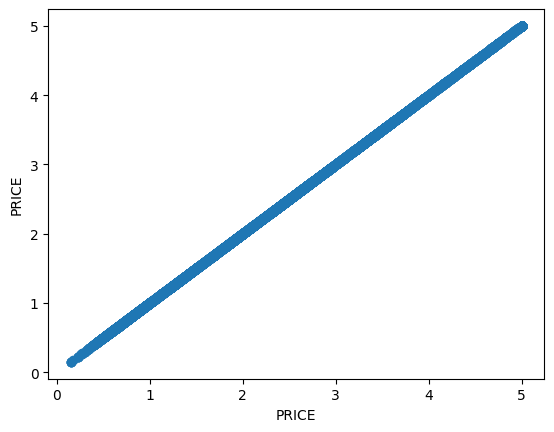

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

for column in df.columns:
    plt.scatter(df[column], df["PRICE"])
    plt.xlabel(column)
    plt.ylabel("PRICE")
    plt.show()

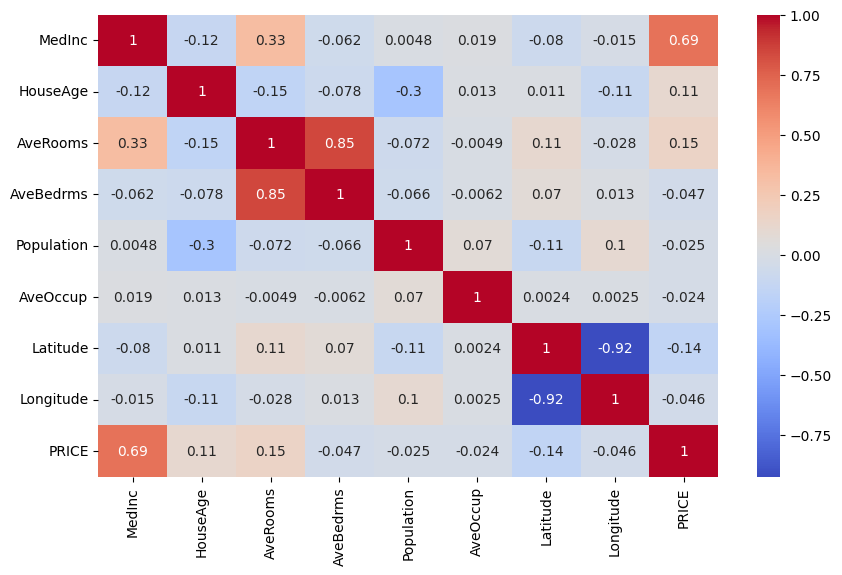

In [54]:

plt.figure(figsize=(10, 6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [55]:
corr_matrix = df.corr().abs()
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
MedInc,1.000000,0.119034,0.326895,0.062040,0.004834,0.018766,0.079809,0.015176,0.688075
HouseAge,0.119034,1.000000,0.153277,0.077747,0.296244,0.013191,0.011173,0.108197,0.105623
AveRooms,0.326895,0.153277,1.000000,0.847621,0.072213,0.004852,0.106389,0.027540,0.151948
AveBedrms,0.062040,0.077747,0.847621,1.000000,0.066197,0.006181,0.069721,0.013344,0.046701
Population,0.004834,0.296244,0.072213,0.066197,1.000000,0.069863,0.108785,0.099773,0.024650
AveOccup,0.018766,0.013191,0.004852,0.006181,0.069863,1.000000,0.002366,0.002476,0.023737
Latitude,0.079809,0.011173,0.106389,0.069721,0.108785,0.002366,1.000000,0.924664,0.144160
Longitude,0.015176,0.108197,0.027540,0.013344,0.099773,0.002476,0.924664,1.000000,0.045967
PRICE,0.688075,0.105623,0.151948,0.046701,0.024650,0.023737,0.144160,0.045967,1.000000


In [56]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X, Y)

importances = model.feature_importances_

for name,score in zip(X.columns, importances):
    print(name,score)

MedInc 0.5214391890404233
HouseAge 0.05372448109982541
AveRooms 0.04633641147511987
AveBedrms 0.029537853609962913
Population 0.03153170712503778
AveOccup 0.13621942627446906
Latitude 0.09093353754796263
Longitude 0.09027739382719917


## 🎯 Feature & Target Separation

- **X (Features):** Input variables used for prediction  
- **y (Target):** House price (what we want to predict)

We separate them to train the machine learning model correctly.

In [57]:
X = df.drop("PRICE",axis=1)
Y = df["PRICE"]


## 🔀 Train-Test Split

We split the dataset into:
- **Training set (80%)** → used to train the model  
- **Testing set (20%)** → used to evaluate performance  

This ensures the model generalizes well to unseen data.

In [58]:
from sklearn.model_selection import train_test_split


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


## ⚙️ Model Training - Linear Regression

We use Linear Regression to model the relationship between features and house price.

It assumes a linear relationship between input variables and the target.

In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 📊 Model Evaluation

We evaluate the model using:

- **MAE (Mean Absolute Error):** Average prediction error  
- **RMSE (Root Mean Squared Error):** Penalizes larger errors  
- **R² Score:** Measures how well the model explains variance  

These metrics help us understand model performance.

In [60]:
Y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("mean absloute error: ", mae )
print("Mean squared error: ", mse)
print("Root mean squared error", rmse)
print("R2 score", r2)

mean absloute error:  0.5332001304956548
Mean squared error:  0.5558915986952444
Root mean squared error 0.7455813830127764
R2 score 0.5757877060324508


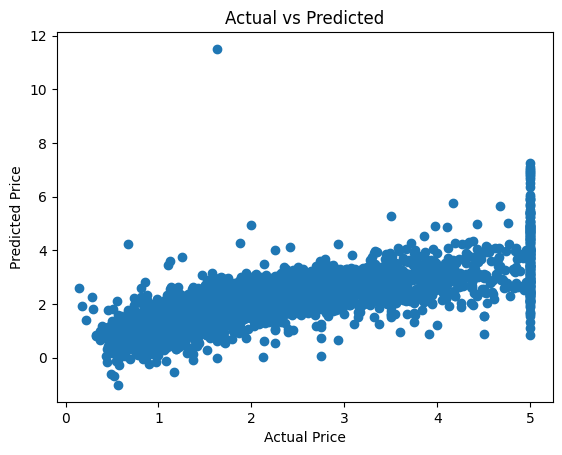

In [61]:
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

## ⚖️ Feature Scaling

We apply StandardScaler to normalize features:

\[
z = \frac{x - \mu}{\sigma}
\]

This ensures all features are on the same scale, which is important for many ML algorithms.

## 🔄 Machine Learning Pipeline

We use a pipeline to combine:
- Feature scaling
- Model training

This ensures:
- Clean workflow
- No data leakage
- Reproducible results

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("Scaler", StandardScaler()), ("Model", LinearRegression())
])
pipeline.fit(X_train, Y_train)

Y_pred = pipeline.predict(X_test)

In [63]:
scaler = pipeline.named_steps.Scaler
print(scaler.mean_)
print(scaler.scale_)

[ 3.88075426e+00  2.86082849e+01  5.43523502e+00  1.09668475e+00
  1.42645300e+03  3.09696119e+00  3.56431492e+01 -1.19582290e+02]
[1.90423626e+00 1.26021177e+01 2.38730258e+00 4.33201426e-01
 1.13702195e+03 1.15783935e+01 2.13660060e+00 2.00559281e+00]


In [64]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("mean absloute error: ", mae )
print("Mean squared error: ", mse)
print("Root mean squared error", rmse)
print("R2 score", r2)

mean absloute error:  0.5332001304956565
Mean squared error:  0.5558915986952444
Root mean squared error 0.7455813830127764
R2 score 0.5757877060324508


In [65]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("mean absloute error: ", mae )
print("Mean squared error: ", mse)
print("Root mean squared error", rmse)
print("R2 score", r2)

mean absloute error:  0.5332001304956565
Mean squared error:  0.5558915986952444
Root mean squared error 0.7455813830127764
R2 score 0.5757877060324508


In [66]:
X_scaled = pipeline.named_steps["Scaler"].transform(X_train)
X_scaled


array([[-0.326196  ,  0.34849025, -0.17491646, ...,  0.05137609,
        -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, ..., -0.11736222,
        -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, ..., -0.03227969,
        -0.46014647, -0.44760309],
       ...,
       [-0.49697313,  0.58654547, -0.60675918, ...,  0.02030568,
        -0.75500738,  0.59946887],
       [ 0.96545045, -1.07984112,  0.40217517, ...,  0.00707608,
         0.90651045, -1.18553953],
       [-0.68544764,  1.85617335, -0.85144571, ..., -0.08535429,
         0.99543676, -1.41489815]], shape=(16512, 8))

In [67]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X_train.columns, index=X_train.index)
X_scaled_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
8267,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
17445,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
14265,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
2271,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551
...,...,...,...,...,...,...,...,...
11284,1.307215,0.507194,0.290620,-0.393391,-0.675847,-0.005588,-0.872016,0.808883
11964,-0.436266,0.348490,0.600411,0.398898,0.287195,0.069722,-0.759688,1.073144
5390,-0.496973,0.586545,-0.606759,-0.039216,0.289833,0.020306,-0.755007,0.599469
860,0.965450,-1.079841,0.402175,-0.066265,0.308303,0.007076,0.906510,-1.185540


In [68]:
comparison = pd.DataFrame({
    "Original": X_train.iloc[:, 0], "Scaled": X_scaled_df.iloc[:, 0]
})
comparison.head()

,Original,Scaled
14196,3.2596,-0.326196
8267,3.8125,-0.035843
17445,4.1563,0.144701
14265,1.9425,-1.017864
2271,3.5542,-0.171488


## 📈 Visualization

We visualize:
- Distribution of features
- Relationship between actual and predicted values

This helps in understanding model behavior.

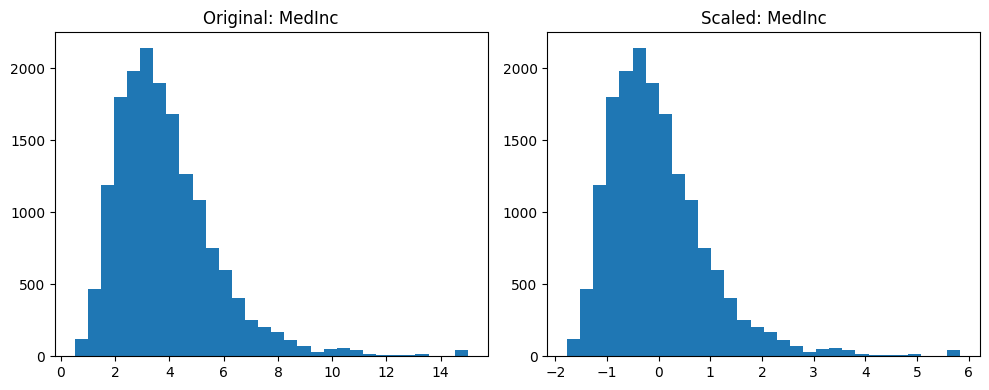

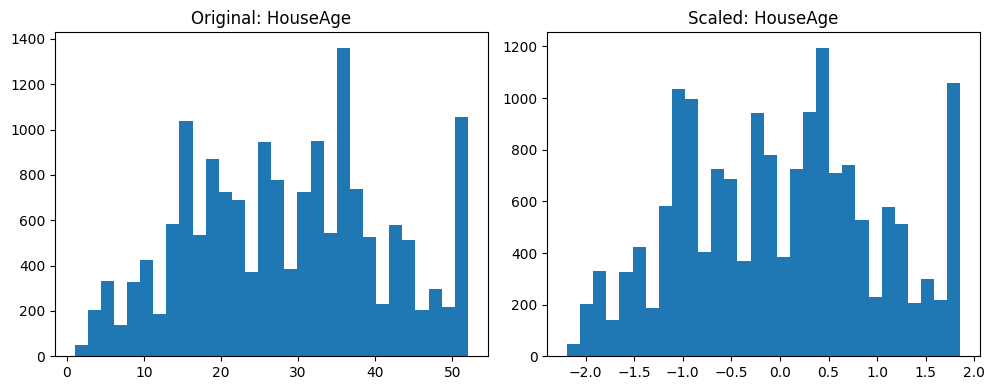

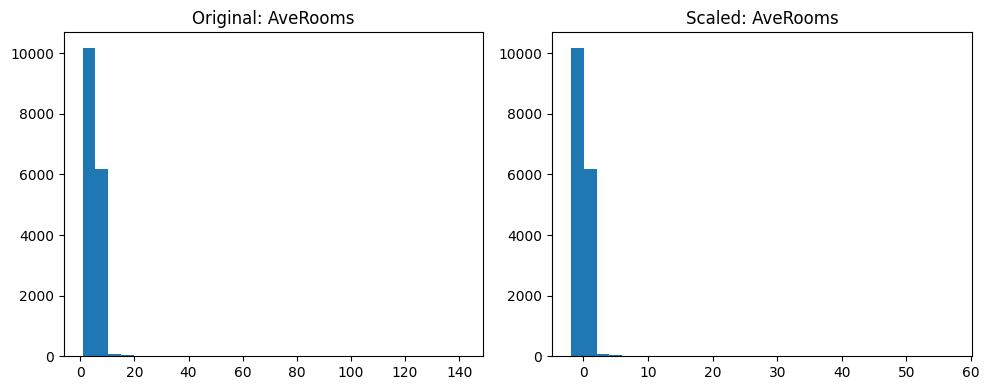

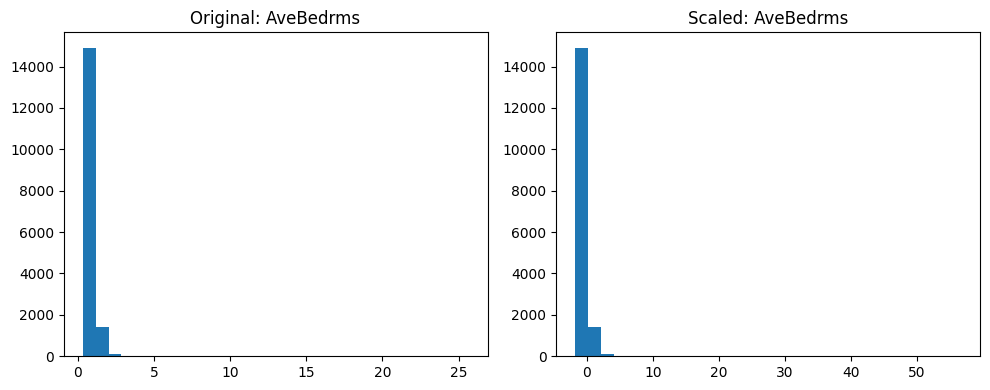

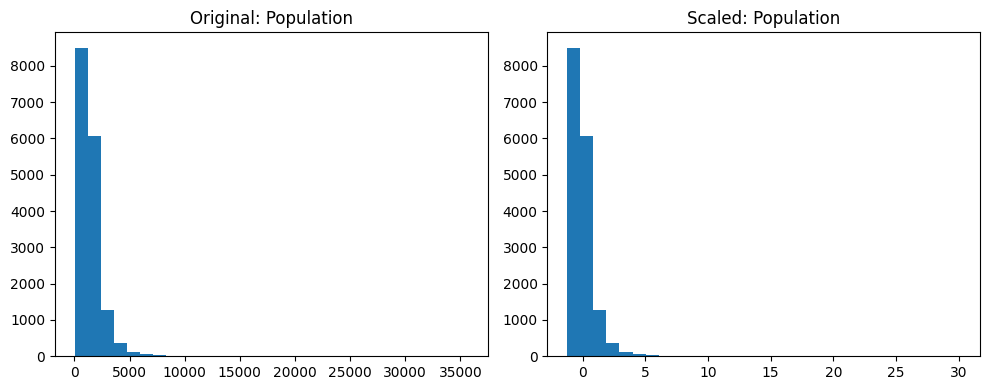

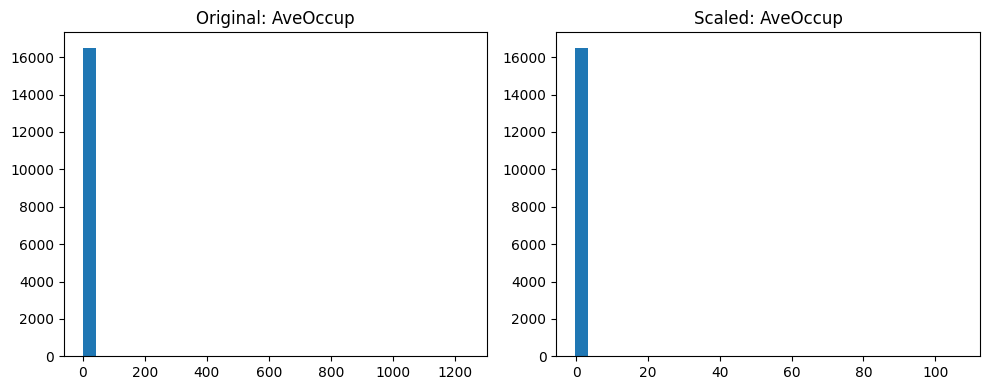

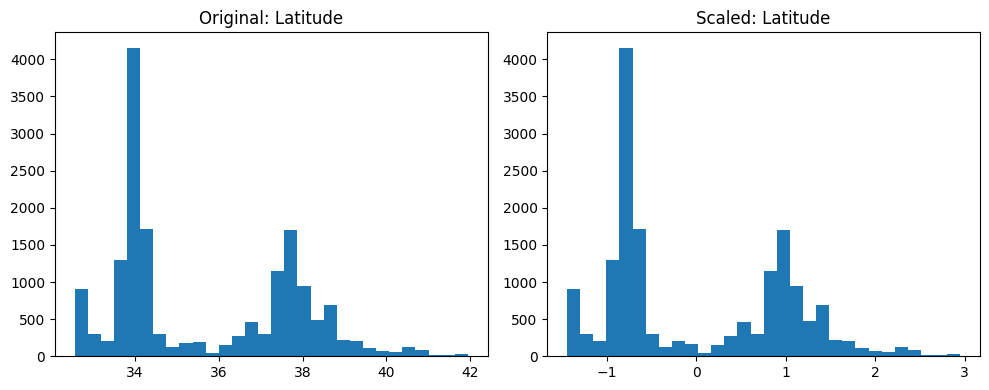

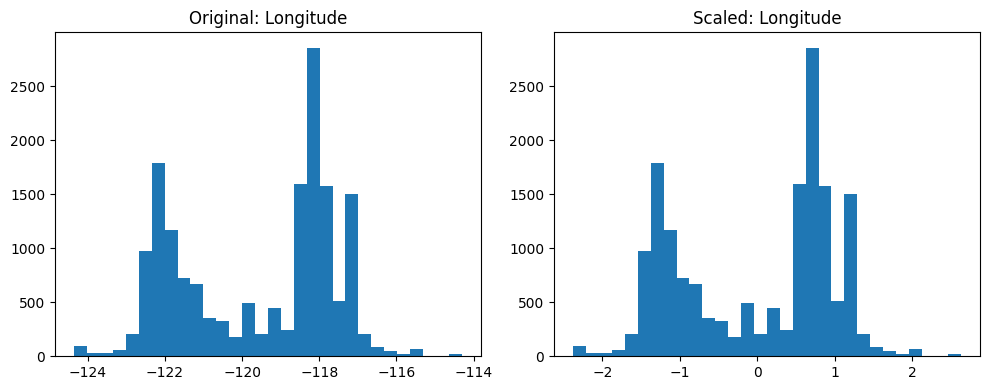

In [69]:
for col in X_train.columns:
    plt.figure(figsize=(10, 4))

    # Original
    plt.subplot(1, 2, 1)
    plt.hist(X_train[col], bins=30)
    plt.title(f"Original: {col}")

    # Scaled
    plt.subplot(1, 2, 2)
    plt.hist(X_scaled_df[col], bins=30)
    plt.title(f"Scaled: {col}")

    plt.tight_layout()
    plt.show()

## 🧠 Conclusion

- Built a baseline Linear Regression model  
- Achieved moderate performance (R² ≈ 0.57)  
- Observed that scaling does not significantly impact Linear Regression  
- Identified scope for improvement using advanced models  

## 🚀 Next Steps
- Try Ridge and Lasso Regression  
- Use Random Forest for better performance  
- Perform feature engineering  
- Integrate into Streamlit UI